In [1]:
%reload_ext autoreload
%autoreload 2

This notebook performs the target identification for all ADPKD-screend compounds through the [Papyrus dataset](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-022-00672-x). The version `05.6` was used for this project, with a subset of minimum quality set to `medium`, and organisms filtered to *Homo sapiens*, *Mus musculus*, *Rattus norvegicus*. For more details on the dataset collection, check the [First time - identified targets not saved](#first-time---identifided-targets-not-saved) section below.

The target identification is simplified by using a python package included in this repository, the `papyrusBioactivityLinker`. Upon doing the steps described above, the collected subset of the Papyrus Dataset and the screening data used for target identification are easily loaded to instantiate a `PapyrusCompoundLinker` class.

To load the results as reported in the manuscript, load the screening dataset and the identified targets directly by running the cells under [Loading from saved bioactivitylinker](#loading-from-saved-bioactivitylinker)

# Imports

In [ ]:
import re
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from chemFilters.chem.standardizers import ChemStandardizer, InchiHandling
from chemFilters.logger import logger, setup_logger
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
from papyrusBioactivityLinker.datalinker import PapyrusCompoundLinker
from UniProtMapper import ProtMapper

# Define functions

In [ ]:
def updateSmilesInchiConnect(_df, smiles_col):
    """function to add standardized smiles, and their respective inchi and inchikeys to a dataframe.
    Smiles will be loaded from df[smiles_col]
    

    Args:
        _df: dataframe to add the columns.
        smiles_col: column name with the smiles strings to be standardized
        
    Returns:
        _df: dataframe with added columns std_smiles, inchi, inchikeys, connectivity
    """
    standardizer = ChemStandardizer(
        method="papyrus",
        rdkit_loglevel="critical",
        isomeric=True,
        from_smi=True,
        progress=True,
    )
    print(f"Standardizing {smiles_col}")
    std_smiles = standardizer(_df[smiles_col])

    # output supression - cpds not standardized by papyrus will be None - errors printed by InchiHandling
    stream = StringIO()
    logger.remove()
    logger.add(stream)

    inchi_calc = InchiHandling(convert_to="inchi", rdkit_loglevel="critical", from_smi=True)
    inchis = inchi_calc(std_smiles)
    inchi_k_calc = InchiHandling(convert_to="inchikey", rdkit_loglevel="critical", from_smi=True)
    inchi_keys = inchi_k_calc(std_smiles)
    connect_calc = InchiHandling(convert_to="connectivity", rdkit_loglevel="critical", from_smi=True)
    connectivities = connect_calc(std_smiles)
    _df = _df.assign(std_smiles=std_smiles, inchi=inchis, inchikeys=inchi_keys, connectivity=connectivities)

    logger.remove()  # remove the stream handler
    setup_logger()  # restore chemFilters logger to normal

    return _df

In [ ]:
def clean_protein_name(name):
    # Split by comma if present and take first part
    first_part = name.split(",")[0]
    # Find everything in parenthesis
    matches = re.findall(r"\([^()]*\)", first_part)
    # Keep only the base name and first info under parenthesis if exists
    if matches:
        base_name = re.split(r"\([^()]*\)", first_part)[0].strip()
        return f"{base_name} {matches[0]}"
    else:
        return first_part.strip()


def parse_entry(entry):
    superfamily, family, subfamily = None, None, None
    superfamily_patt = re.compile("\ssuperfamily$")
    family_patt = re.compile("\sfamily$")
    subfamily_patt = re.compile("\ssubfamily$")

    for e in entry.split(","):
        if e.startswith(" "):
            e = e.lstrip(" ")
        if superfamily_patt.findall(e):
            superfamily = re.sub(superfamily_patt, "", e)
        if family_patt.findall(e):
            family = re.sub(family_patt, "", e)
        if subfamily_patt.findall(e):
            subfamily = re.sub(subfamily_patt, "", e)
    return superfamily, family, subfamily


def process_protein_families(entry):
    """Parse UniProt `protein family` entry into superfamily, family and subfamily.

    Args:
        entry: UniProt protein family entry.

    Returns:
        pd.Series: superfamily, family, subfamily.
    """    
    if ";" in entry:
        entries = entry.split(";")
    else:
        entries = [entry]
    total_sub, total_fam, total_sup = [], [], []
    for e in entries:
        sup, fam, sub = parse_entry(e)
        if sup is not None:
            total_sub.append(sup)
        if fam is not None:
            total_fam.append(fam)
        if sub is not None:
            total_sup.append(sub)
    return pd.Series(
        {
            "superfamily": ";".join(total_sub),
            "family": ";".join(total_fam),
            "subfamily": ";".join(total_sup),
        }
    )

# Color palette

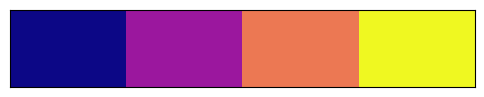

In [ ]:
fig, ax = plt.subplots(figsize=(6, 1))
scalar_mappable = ScalarMappable(cmap="plasma")
colors = scalar_mappable.to_rgba(range(4), alpha=1).tolist()
ax.imshow([colors], aspect="auto")
ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Remove y-axis ticks
plt.show()

# Target identification

## First time - identifided targets not saved

In [ ]:
hit_id_root = (Path() / "../").resolve() / "data/adpkd_screening/identified_hits"
hit_id_path = sorted(hit_id_root.glob("*hitflag*"))[-1] # take the latest generated hit-flagged file

df = pd.read_csv(hit_id_path)

controls_list = ["Staurosporin", "DMSO", "DMSO+FSK", "Colforsin"]
todrop_idxs = df.query("Compound.isin(@controls_list)").index

df = (
    df.assign(Activity=lambda x: np.where(x.Antineoplastic, "antineoplastic", x.Activity))
    .drop(
        columns=[
            "Antineoplastic",
            "standardised_smiles",
            "StandardizationFLAG",
            "Connectivity",
            "Certainty",
        ]
    )
    .drop(index=todrop_idxs.tolist())
    .reset_index(drop=True)
)
print(df.shape)  # 2558
df.head(2)

[11:55:28] Initializing Normalizer
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.


(2681, 4)


,Compound,Activity,SMILES,Screening
0,1-(2-methoxyphenyl)pierazine hydrochloride,inactive,COc1c(N2CCNCC2)cccc1,spectrum
1,1-hydroxy-3.6.7-trimethoxy-2.8-diprenylxanthone,inactive,COc1c(CC=C(C)C)c(O)c2c(=O)c3c(CC=C(C)C)c(OC)c(...,spectrum


In [ ]:
final_df = updateSmilesInchiConnect(df, "SMILES")

Standardizing SMILES


  0%|          | 0/2681 [00:00<?, ?it/s]

100%|██████████| 2681/2681 [00:00<00:00, 14620.61it/s]


In [4]:
print("Shape of the dataset before dropping nans:", final_df.shape, "\n")
final_df = final_df.replace({None: np.nan}).dropna()
print("Shape of the dataset after dropping nans:", final_df.shape, "\n")

# drop duplicates as well
shape_before = final_df.shape
final_df = final_df.drop_duplicates(subset=["connectivity", "Activity"])
print("Shape of the dataset after dropping duplicates:", final_df.shape, "\n")
print("Number of duplicated compounds dropped:", shape_before[0] - final_df.shape[0])

Shape of the dataset before dropping nans: (2681, 8) 

Shape of the dataset after dropping nans: (2123, 8) 

Shape of the dataset after dropping duplicates: (2080, 8) 

Number of duplicated compounds dropped: 43


In [5]:
final_df["Activity"].value_counts()

Activity
inactive          1862
reducer            115
antineoplastic      56
enhancer            47
Name: count, dtype: int64

In [ ]:
from papyrus_scripts import download_papyrus

download_papyrus(version="05.6", progress=True, nostereo=True, stereo=False, descriptors=False, only_pp=False)

Number of files to be downloaded: 4
Total size: 777MB


In [6]:
linker = PapyrusCompoundLinker(df=final_df, smiles_col="std_smiles", bioactivity_col="Activity")
linker.prepareDataset()
print("Done!")

Standardizing SMILES...


100%|██████████| 2080/2080 [00:00<00:00, 11091.50it/s]


Adding SMILES connectivities...


100%|██████████| 2080/2080 [00:00<00:00, 11967.76it/s]


0 failed to be standardized and will be dropped.
Done!


In [ ]:
linker.applyPapyrusFilters(
    ids=linker.df.connectivity.tolist(), organisms=["Homo sapiens", "Mus musculus", "Rattus norvegicus"]
)
linker.linkData()

  0%|          | 0/60 [00:00<?, ?it/s]

Size of the Papyrus dataframe: 37242
1626unique connectivities.
1839unique accessions.
Index(['Activity_ID', 'Quality', 'source', 'CID', 'SMILES', 'connectivity',
       'InChIKey', 'InChI', 'InChI_AuxInfo', 'target_id', 'TID', 'accession',
       'Protein_Type', 'AID', 'doc_id', 'Year', 'all_doc_ids', 'all_years',
       'type_IC50', 'type_EC50', 'type_KD', 'type_Ki', 'type_other',
       'Activity_class', 'relation', 'pchembl_value', 'pchembl_value_Mean',
       'pchembl_value_StdDev', 'pchembl_value_SEM', 'pchembl_value_N',
       'pchembl_value_Median', 'pchembl_value_MAD', 'Organism'],
      dtype='object')


100%|██████████| 7/7 [00:00<00:00, 17.99it/s]

450 compounds not found in papyrus dataset.
Dropping compounds...


In [95]:
papyrus_root = (Path() / "../").resolve() / "data/papyrus_data/"
linker.save(name="ADPKD-Booij-Reanalyzed", save_path=str(papyrus_root), force=True)

Creating directory /zfsdata/data/david/cyst-to-target-and-back/data/papyrus_data/ADPKD-Booij-Reanalyzed...


## Loading from saved bioactivityLinker

In [97]:
papyrus_root = (Path() / "../").resolve() / "data/papyrus_data/"

linker = PapyrusCompoundLinker.fromFile(papyrus_root / "ADPKD-Booij-Reanalyzed")

# Venn Diagram

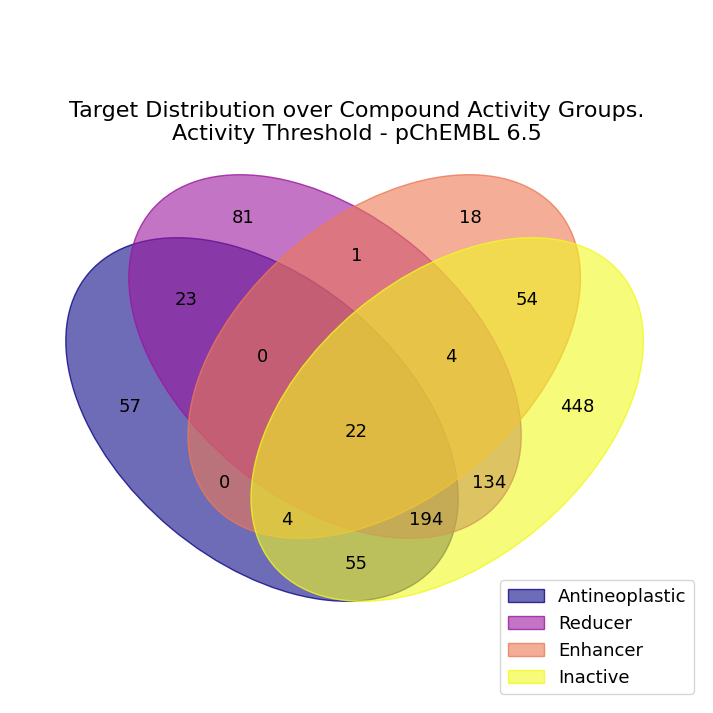

In [98]:
target_dict = linker.getTargetSets()
order = [
    "antineoplastic",
    "reducer",
    "enhancer",
    "inactive",
]
toplot_dict = {}
for val in order:
    toplot_dict[val.capitalize()] = linker.bioactivity_dict[val]

toplot_dict.keys()

fig, ax = plt.subplots(figsize=(9, 9))

linker.bioactivityVenn(toplot_dict, ax=ax)
ax.set_title(
    "Target Distribution over Compound Activity Groups.\nActivity Threshold - pChEMBL 6.5",
    y=0.8,
    fontsize=16,
)

fig.savefig(
    "../figures/ADPKD-Bioactivity_and_TargetSpace.png", bbox_inches="tight", dpi=300, facecolor="white"
)

# Hit identification quantification

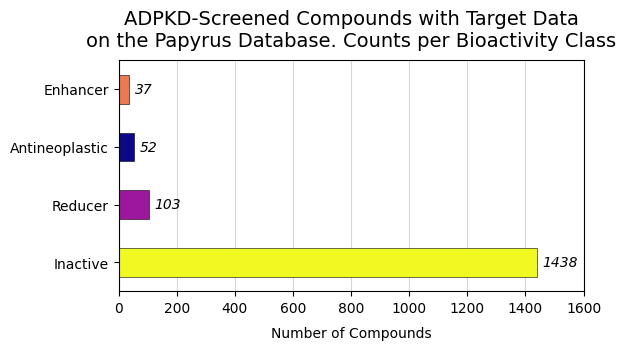

In [ ]:
from matplotlib.cm import ScalarMappable

scalar_mappable = ScalarMappable(cmap="plasma")
colors = scalar_mappable.to_rgba(range(4), alpha=1).tolist()
classes = ["Antineoplastic", "Reducer", "Enhancer", "Inactive"]
colormap = dict(zip(classes, colors))

toplot_df = linker.df.bioactivity.str.capitalize().value_counts()
use_colors = [colormap[k] for k in toplot_df.index]


fig, ax = plt.subplots(figsize=(6, 3))
ax = toplot_df.plot.barh(color=use_colors, edgecolor="black", linewidth=0.4)

for idx, value in enumerate(toplot_df):
    label_x_pos = value + 20  # You can adjust the offset value for the text position
    ax.text(label_x_pos, idx, value, ha="left", va="center", fontstyle="italic")

ax.set_xlim(0, 1600)
ax.grid(axis="x", alpha=0.5)
ax.set_axisbelow(True)

ax.set_title(
    # "ADPKD Screening Compounds for each of the\nBioactivity Classes with Target Data in Papyrus",
    "ADPKD-Screened Compounds with Target Data\non the Papyrus Database. Counts per Bioactivity Class",
    y=1.025,
    fontsize=14,
)
ax.set_xlabel("Number of Compounds")
ax.xaxis.set_label_coords(0.5, -0.15)
ax.set_ylabel("")

fig.savefig(
    "../figures/ADPKD-Compound_Bioactivity_Counts-Has_Papyrus_Data.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

# Target prioritization

### Fetch target information from UniProt

In [ ]:
protein_ids = linker.papyrusDataset["accession"].unique().tolist()

mapper = ProtMapper()
result, failed = mapper.get(
    ids=protein_ids,
    fields=[
        "protein_name",
        "organism_name",
        "gene_primary",
        "gene_names",
        "protein_families",
        "xref_chembl",
    ],
)

Fetched: 497 / 500
Fetched: 500 / 500
Fetched: 499 / 500
Fetched: 337 / 339


In [48]:
result["Protein names"] = result["Protein names"].apply(clean_protein_name)
result["Organism"] = result.Organism.apply(lambda x: x.split("(")[1].strip(")"))

result = result.join(result["Protein families"].apply(lambda x: process_protein_families(x))).replace(
    {"": np.nan}
)

result = result.assign(nameOrg=lambda x: x["Protein names"] + " (" + x["Organism"] + ")")

In [ ]:
name_dict = dict(zip(result["From"], result["nameOrg"]))


def get_targ_only(targets):
    return list(set([t.split("_")[0] for t in targets.split(";")]))


subset = linker.df[linker.df["Targets_6.5"].notna()]
subset = subset.assign(targets_only=subset["Targets_6.5"].apply(get_targ_only)).explode("targets_only")


scored_targs = (
    subset.groupby("targets_only")["Activity"]
    .value_counts()
    .unstack()
    .fillna(0)
    .astype(int)
    .reset_index()
    .assign(
        total=lambda x: x["reducer"] + x["enhancer"] + x["antineoplastic"] + x["inactive"],
        reduc_ratio=lambda x: x["reducer"] / x["total"],
        enhanc_ratio=lambda x: x["enhancer"] / x["total"],
        antineo_ratio=lambda x: x["antineoplastic"] / x["total"],
        identifier=lambda x: x["targets_only"].map(name_dict),
    )
    .replace(np.inf, np.nan)
    .sort_values("reduc_ratio", ascending=False)
    #  .query('antineoplastic <= 2')
    .reset_index(drop=True)
)

scored_targs = scored_targs.merge(result, left_on="targets_only", right_on="From")
# scored_targs.to_csv('scored_targets_6.5.csv', index=False)


In [ ]:
# TODO: these were targets deemed interesting for downstream modeling tasks 
# Criteria was to have at least 200 bioactivity data points in ChEMBL with confidence
# scores of 7, 8 or 9 (binding and functional assays were considered)
chembl_ids = [
    "CHEMBL1293256",
    "CHEMBL1293278",
    "CHEMBL1293316",
    "CHEMBL1741165",
    "CHEMBL1980",
    "CHEMBL1994",
    "CHEMBL204",
    "CHEMBL226",
    "CHEMBL227",
    "CHEMBL233",
    "CHEMBL236",
    "CHEMBL2535",
    "CHEMBL256",
    "CHEMBL286",
    "CHEMBL2998",
    "CHEMBL3706",
    "CHEMBL402",
    "CHEMBL4105907",
    "CHEMBL4805",
    "CHEMBL5409",
    "CHEMBL5971",
    "CHEMBL6152",
]

/tmp/ipykernel_3495114/2571462516.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")


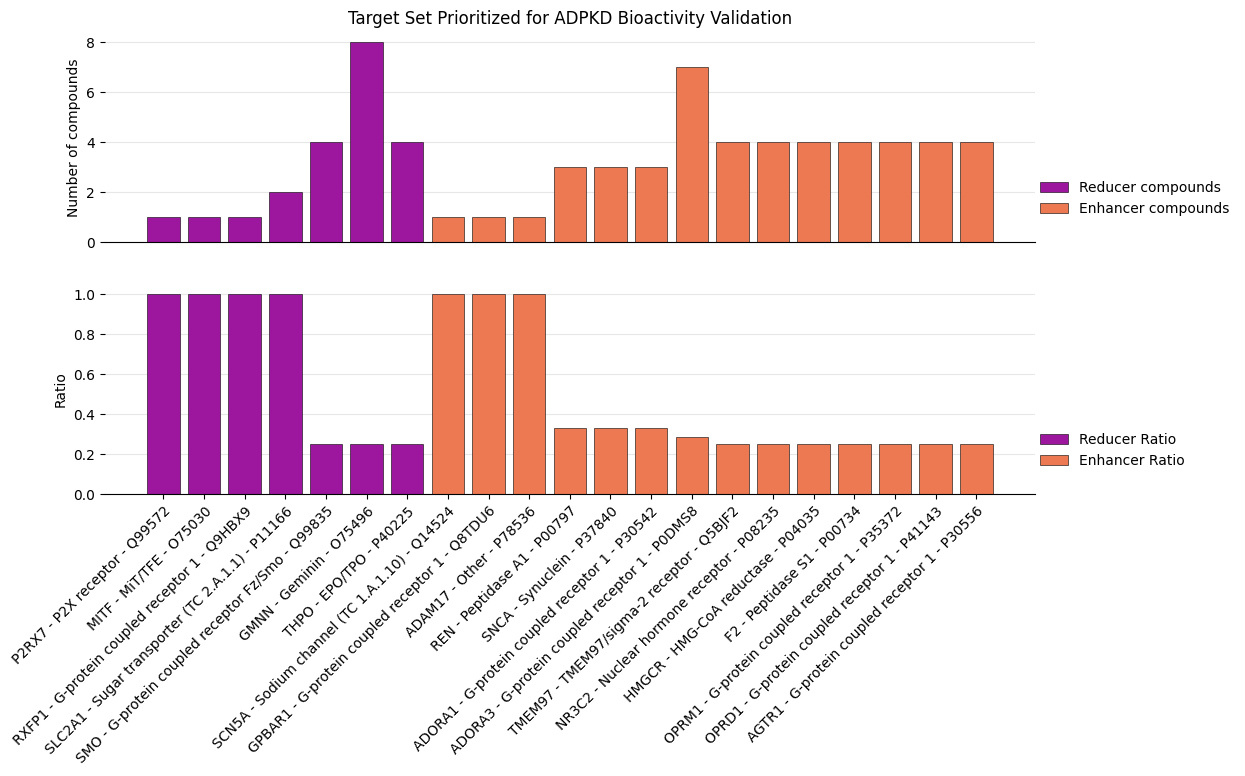

In [93]:
toplot_df = (
    scored_targs.sort_values(["reduc_ratio", "enhanc_ratio"], ascending=False)
    .query("~ChEMBL.isna()")
    .assign(ChEMBL=lambda x: x["ChEMBL"].apply(lambda y: y.split(";")[0]))
    .query("~family.fillna('').str.contains('kinase|cyclin', case=False)")
    .query("reduc_ratio > 0.2 | enhanc_ratio > 0.2")
    .query("antineo_ratio == 0")
    .query("Organism.fillna('').str.contains('Human', regex=False)")
    .rename(columns={"Gene Names (primary)": "primary_gene_name"})
    .assign(
        plot_identifier=lambda x: x["primary_gene_name"]
        + " - "
        + x["family"].fillna("Other")
        + " - "
        + x["targets_only"]
    )
    .melt(
        [
            "targets_only",
            "ChEMBL",
            "identifier",
            "primary_gene_name",
            "Gene Names",
            "family",
            "plot_identifier",
            "total",
            "nameOrg",  # ADDED
        ],
        value_vars=["reduc_ratio", "enhanc_ratio"],
    )
    # .query("primary_gene_name in @gene_names")
    .replace({"enhanc_ratio": "Enhancer Ratio", "reduc_ratio": "Reducer Ratio"})
    .rename(columns={"targets_only": "UniProtID", "Gene Names": "gene_names"})
    .query("value > 0")
    .query("ChEMBL.isin(@chembl_ids)")
)

scalar_mappable = ScalarMappable(cmap="plasma")
colors = scalar_mappable.to_rgba(range(4), alpha=1).tolist()
colors = [colors[1], colors[2]]
spines = ["right", "left", "top"]

color_mapping = {
    "Reducer Ratio": [0.610667, 0.090204, 0.619951, 1.0],
    "Enhancer Ratio": [0.928329, 0.472975, 0.326067, 1.0],
}

fig, axes = plt.subplots(nrows=2, figsize=(12, 6))
for idx, row in toplot_df.iterrows():
    color = color_mapping[row["variable"]]
    axes[0].bar(row["plot_identifier"], row["total"], color=color, edgecolor="black", linewidth=0.4)
    axes[1].bar(row["plot_identifier"], row["value"], color=color, edgecolor="black", linewidth=0.4)

for spine in spines:
    axes[0].spines[spine].set_visible(False)
    axes[1].spines[spine].set_visible(False)

axes[0].set_ylabel("Number of compounds")
axes[0].set_title(
    "Target Set Prioritized for ADPKD Bioactivity Validation",
)
axes[0].set_xticks([])
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_axisbelow(True)
custom_labels = ["Reducer compounds", "Enhancer compounds"]

legend_elements = [
    Patch(facecolor=color_mapping[key], edgecolor="black", linewidth=0.4, label=lab)
    for key, lab in zip(color_mapping, custom_labels)
]

axes[0].legend(
    handles=legend_elements,
    bbox_to_anchor=(1.0, 0.1),
    loc="lower left",
    borderaxespad=0,
    frameon=False,
)

legend_elements = [
    Patch(facecolor=color_mapping[key], edgecolor="black", linewidth=0.4, label=key) for key in color_mapping
]

axes[1].legend(
    handles=legend_elements,
    bbox_to_anchor=(1.0, 0.1),
    loc="lower left",
    borderaxespad=0,
    frameon=False,
)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)
axes[1].set_ylabel("Ratio")

fig.savefig(
    "../figures/ADPKD-Prioritized_Target_Set.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)